# COSC 2671 — Assignment 2 | Group 8
## Notebook 2: Initial Insights and Network Analysis

Loads cleaned data and performs exploratory analysis followed by full network analysis.

**Part 1 — Initial Insights:** Toot volume over time, instance distribution, 
hashtag breakdown, snapshot distribution, user join year chart.

**Part 2 — Network Analysis:** Builds user interaction and instance federation 
networks. Computes PageRank, in-degree and betweenness centrality. Runs Louvain 
community detection. Exports GraphML for Gephi visualisation.

**Input Folder:** mastodon_data_clean/
**Output Folder:** mastodon_data_network/
**Run after:** Notebook 1

## INITIAL ANLAYSIS

In [1]:
import pandas as pd
import networkx as nx
import community as community_louvain
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from collections import Counter
from networkx.algorithms.centrality import betweenness_centrality as _betweenness
import warnings
warnings.filterwarnings("ignore")

df_toots_clean  = pd.read_csv("mastodon_data_clean/toots_clean.csv")
df_toots_en     = pd.read_csv("mastodon_data_clean/toots_english.csv")
df_users_clean  = pd.read_csv("mastodon_data_clean/users_clean.csv")
df_edges_all    = pd.read_csv("mastodon_data_clean/edges_all.csv")
df_reply_clean  = pd.read_csv("mastodon_data_clean/edges_reply_clean.csv")
df_boost_clean  = pd.read_csv("mastodon_data_clean/edges_boost_clean.csv")
df_instances    = pd.read_csv("mastodon_data_clean/instances.csv")

SNAPSHOTS = [
    "Snapshot 1 — Peak Exodus (Oct–Dec 2022)",
    "Snapshot 2 — Post Settling (2023)",
    "Snapshot 3 — Current State (2024–2026)",
]

print(f"Toots (clean):   {len(df_toots_clean):,}")
print(f"Toots (english): {len(df_toots_en):,}")
print(f"Users:           {len(df_users_clean):,}")
print(f"Edges (all):     {len(df_edges_all):,}")
print(f"Reply edges:     {len(df_reply_clean):,}")
print(f"Boost edges:     {len(df_boost_clean):,}")

Toots (clean):   5,436
Toots (english): 4,485
Users:           3,298
Edges (all):     2,413
Reply edges:     493
Boost edges:     1,920


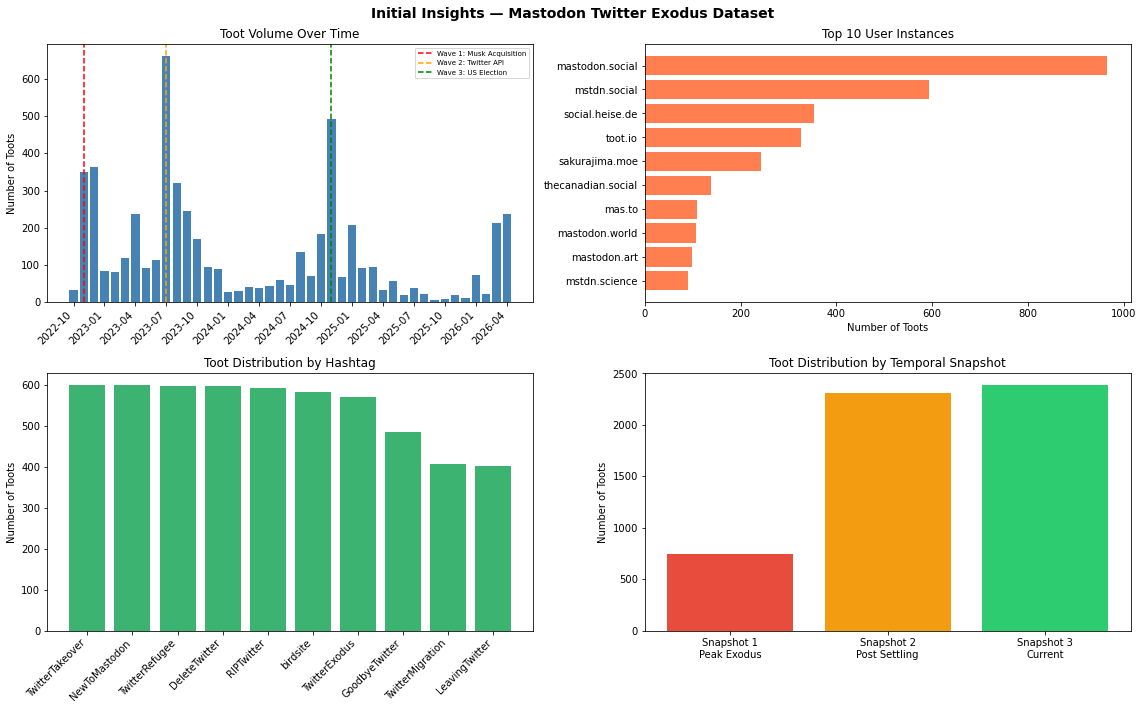

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Toot volume over time with migration waves
monthly    = df_toots_clean.groupby("year_month").size()
month_list = list(monthly.index)
axes[0,0].bar(range(len(monthly)), monthly.values, color="steelblue")
axes[0,0].set_xticks(range(0, len(monthly), 3))
axes[0,0].set_xticklabels(monthly.index[::3], rotation=45, ha="right")
axes[0,0].set_title("Toot Volume Over Time")
axes[0,0].set_ylabel("Number of Toots")
for ym, color, label in [
    ("2022-11", "red",    "Wave 1: Musk Acquisition"),
    ("2023-07", "orange", "Wave 2: Twitter API"),
    ("2024-11", "green",  "Wave 3: US Election"),
]:
    if ym in month_list:
        axes[0,0].axvline(x=month_list.index(ym), color=color,
                          linestyle="--", label=label)
axes[0,0].legend(fontsize=7)

# 2. Top 10 user instances
top_inst = df_toots_clean["user_instance"].value_counts().head(10)
axes[0,1].barh(top_inst.index[::-1], top_inst.values[::-1], color="coral")
axes[0,1].set_title("Top 10 User Instances")
axes[0,1].set_xlabel("Number of Toots")

# 3. Hashtag breakdown
hashtag_counts = df_toots_clean["hashtag_searched"].value_counts()
axes[1,0].bar(hashtag_counts.index, hashtag_counts.values, color="mediumseagreen")
axes[1,0].set_xticklabels(hashtag_counts.index, rotation=45, ha="right")
axes[1,0].set_title("Toot Distribution by Hashtag")
axes[1,0].set_ylabel("Number of Toots")

# 4. Snapshot distribution
snap_order  = [
    "Snapshot 1 — Peak Exodus (Oct–Dec 2022)",
    "Snapshot 2 — Post Settling (2023)",
    "Snapshot 3 — Current State (2024–2026)"
]
snap_counts = df_toots_clean["snapshot"].value_counts()
labels      = ["Snapshot 1\nPeak Exodus", "Snapshot 2\nPost Settling", "Snapshot 3\nCurrent"]
vals        = [snap_counts.get(s, 0) for s in snap_order]
axes[1,1].bar(labels, vals, color=["#E74C3C", "#F39C12", "#2ECC71"])
axes[1,1].set_title("Toot Distribution by Temporal Snapshot")
axes[1,1].set_ylabel("Number of Toots")

plt.suptitle("Initial Insights — Mastodon Twitter Exodus Dataset",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("mastodon_data_network/initial_insights.png", dpi=150, bbox_inches="tight")
plt.show()

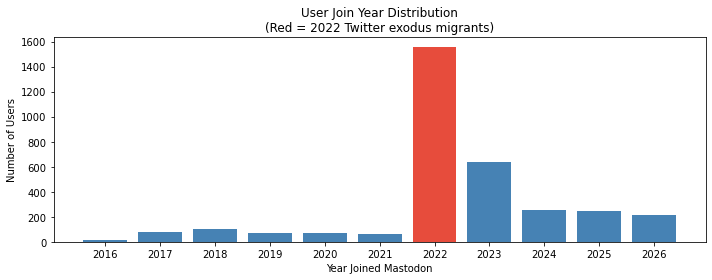

=== BASIC STATS ===
Total toots:         5,436
Unique users:        3,298
Reply edges:         493
Boost edges:         1,920
Unique instances:    356
Migrants (2022):     1,556
Pre-existing:        1,742
Avg reblogs/toot:    5.03
Avg favourites/toot: 1.84

Language breakdown:
language
en    4485
de     582
fr      53
es      34
pl      29
ja      24


In [3]:
# User join year distribution
plt.figure(figsize=(10, 4))
join_dist = df_users_clean["join_year"].value_counts().sort_index()
colors    = ["#E74C3C" if y == 2022 else "steelblue" for y in join_dist.index]
plt.bar(join_dist.index.astype(str), join_dist.values, color=colors)
plt.title("User Join Year Distribution\n(Red = 2022 Twitter exodus migrants)")
plt.xlabel("Year Joined Mastodon")
plt.ylabel("Number of Users")
plt.tight_layout()
plt.savefig("mastodon_data_network/insights_join_years.png", dpi=150)
plt.show()

print("=== BASIC STATS ===")
print(f"Total toots:         {len(df_toots_clean):,}")
print(f"Unique users:        {len(df_users_clean):,}")
print(f"Reply edges:         {len(df_reply_clean):,}")
print(f"Boost edges:         {len(df_boost_clean):,}")
print(f"Unique instances:    {df_toots_clean['user_instance'].nunique():,}")
print(f"Migrants (2022):     {(df_users_clean['join_year']==2022).sum():,}")
print(f"Pre-existing:        {(df_users_clean['join_year']!=2022).sum():,}")
print(f"Avg reblogs/toot:    {df_toots_clean['reblogs_count'].mean():.2f}")
print(f"Avg favourites/toot: {df_toots_clean['favourites_count'].mean():.2f}")
print(f"\nLanguage breakdown:")
print(df_toots_clean["language"].value_counts().head(6).to_string())

## NETWORK ANALYSIS

In [4]:
# Network Evolution across Snapshots listed below

SNAPSHOTS = [
    "Snapshot 1 — Peak Exodus (Oct–Dec 2022)",
    "Snapshot 2 — Post Settling (2023)",
    "Snapshot 3 — Current State (2024–2026)",
]

# Here, we are building a Directed Weighted Graph.
# Weighted means edges have a strength - if User A replied to User B 5 times, the edge weight is 5. 
# This captures how strong a relationship is

def build_graph(edge_df, user_df):
    G = nx.DiGraph()# Directed graph
    # nodes added with attributes
    # edges added with weight - if weight already present. it is incremented
    for _, u in user_df.iterrows():
        G.add_node(str(u["user_id"]),
                   username=u["username"],
                   instance=u["instance"],
                   followers=int(u["followers"]),
                   is_migrant=bool(u["is_migrant"]),
                   join_year=int(u["join_year"]))
    for _, e in edge_df.iterrows():
        src, tgt = str(e["source_user_id"]), str(e["target_user_id"])
        if src != tgt:
            if G.has_edge(src, tgt): G[src][tgt]["weight"] += 1
            else: G.add_edge(src, tgt, weight=1, edge_type=e["edge_type"])
    return G

# Full network
G_full = build_graph(df_edges_all, df_users_clean)

# Per snapshot networks
snapshot_graphs, snapshot_stats = {}, []
for snap in SNAPSHOTS:
    snap_edges = df_edges_all[df_edges_all["snapshot"] == snap]
    G_s  = build_graph(snap_edges, df_users_clean)
    wcc  = list(nx.weakly_connected_components(G_s))
    snapshot_graphs[snap] = G_s
    snapshot_stats.append({
        "snapshot":    snap.split("—")[0].strip(),
        "nodes":       G_s.number_of_nodes(),
        "edges":       G_s.number_of_edges(),
        "density":     round(nx.density(G_s), 6), # Density measures how many edges exist compared to how many COULD exist
        "reciprocity": round(nx.reciprocity(G_s), 4),
        # Low Reciprocity - Posting without many replies (Broadcasting)
        # High Reciprocity - Genuine interactions (multiple replies to the same comment)
        "largest_cc":  max(len(c) for c in wcc) if wcc else 0,
    })

print("=== FULL NETWORK ===")
print(f"  Nodes: {G_full.number_of_nodes():,} | Edges: {G_full.number_of_edges():,}")
print(f"  Density: {nx.density(G_full):.6f} | Reciprocity: {nx.reciprocity(G_full):.4f}")

print(f"\n=== NETWORK EVOLUTION ACROSS SNAPSHOTS ===")
print(f"{'Metric':<15} {'Snapshot 1':>12} {'Snapshot 2':>12} {'Snapshot 3':>12}")
print("-" * 55)
for m in ["nodes", "edges", "density", "reciprocity", "largest_cc"]:
    vals = [str(s[m]) for s in snapshot_stats]
    print(f"{m:<15} {vals[0]:>12} {vals[1]:>12} {vals[2]:>12}")

df_snap_stats = pd.DataFrame(snapshot_stats)

=== FULL NETWORK ===
  Nodes: 5,430 | Edges: 2,358
  Density: 0.000080 | Reciprocity: 0.0051

=== NETWORK EVOLUTION ACROSS SNAPSHOTS ===
Metric            Snapshot 1   Snapshot 2   Snapshot 3
-------------------------------------------------------
nodes                   3426         4343         4305
edges                    139         1137         1091
density              1.2e-05        6e-05      5.9e-05
reciprocity              0.0       0.0035       0.0073
largest_cc                41          314          435


In [5]:
#-------------------- Centrality--------------------------# 
pagerank  = nx.pagerank(G_full, weight="weight")
in_degree = nx.in_degree_centrality(G_full)

# Betweeness bug fix (version issue)
G_undir_bet = G_full.to_undirected()
G_undir_bet.remove_nodes_from(list(nx.isolates(G_undir_bet)))
betweenness = _betweenness(G_undir_bet)

# PageRank identifies users who received the most engagement from other influential users (Quality of connections)
# In-Degree Centrality is a direct measure of how much attention a user receives (Many people boost this user)
# Betweeness Centrality identifies "bridge" users - users who area active on two different communities
df_users_clean["pagerank"]    = df_users_clean["user_id"].astype(str).map(pagerank).fillna(0)
df_users_clean["in_degree"]   = df_users_clean["user_id"].astype(str).map(in_degree).fillna(0)
df_users_clean["betweenness"] = df_users_clean["user_id"].astype(str).map(betweenness).fillna(0)

# Deduplicate users by username + instance combination
# Keeping the one with highest pagerank (most relevant)
df_users_clean = df_users_clean.sort_values("pagerank", ascending=False)
df_users_clean = df_users_clean.drop_duplicates(
    subset=["username", "instance"], keep="first"
).reset_index(drop=True)

print(f"Users after deduplication: {len(df_users_clean)}")
print("=== TOP 10 BY PAGERANK ===")
print(df_users_clean.nlargest(10, "pagerank")[
    ["username", "instance", "followers", "is_migrant", "join_year", "pagerank"]
].to_string(index=False))

print("\n=== TOP 10 BY BETWEENNESS ===")
print(df_users_clean.nlargest(10, "betweenness")[
    ["username", "instance", "followers", "is_migrant", "join_year", "betweenness"]
].to_string(index=False))

print("\n=== MIGRANT vs PRE-EXISTING CENTRALITY ===")
migrants = df_users_clean[df_users_clean["is_migrant"] == True]
pre      = df_users_clean[df_users_clean["is_migrant"] == False]
print(f"{'Metric':<15} {'Migrants':>12} {'Pre-existing':>12}")
print("-" * 41)
for m in ["pagerank", "in_degree", "betweenness"]:
    print(f"{m:<15} {migrants[m].mean():>12.6f} {pre[m].mean():>12.6f}")

#-------------------Community Detection-------------------------# 

# Community detection finds groups of nodes which are densely connected to each other than to rest of network.
G_undir = G_full.to_undirected()
G_undir.remove_nodes_from(list(nx.isolates(G_undir)))

# Louvain algorithm helps in finding communities by maximising modularity
partition   = community_louvain.best_partition(G_undir, weight="weight")
modularity  = community_louvain.modularity(partition, G_undir)
communities = Counter(partition.values())

df_users_clean["community"] = df_users_clean["user_id"].astype(str).map(partition)

print(f"\n=== COMMUNITY DETECTION (LOUVAIN) ===")
print(f"  Communities: {len(communities)} | Modularity: {modularity:.4f}")
print(f"  (>0.3 = meaningful | >0.5 = strong)")
print(f"\n  Top 5 communities:")
for cid, size in communities.most_common(6):
    members = df_users_clean[df_users_clean["community"] == cid]
    if len(members) == 0:
        continue
    migrant_pct = 100 * members["is_migrant"].mean()
    inst_counts = members["instance"].value_counts()
    top_inst    = inst_counts.index[0] if len(inst_counts) > 0 else "unknown"
    print(f"    Community {cid}: {size} members | "
          f"{migrant_pct:.0f}% migrants | "
          f"Top instance: {top_inst}")

Users after deduplication: 1700
=== TOP 10 BY PAGERANK ===
            username                  instance  followers  is_migrant  join_year  pagerank
                 mho           social.heise.de       4463       False       2023  0.061635
fingolas.bsky.social              bsky.brid.gy         42       False       2024  0.026654
        Em0nM4stodon          infosec.exchange      18054        True       2022  0.012304
           flexghost           mastodon.social      10740        True       2022  0.007944
      AnneTheWriter1          universeodon.com       3107       False       2023  0.006279
     thesiswhisperer                aus.social       6002        True       2022  0.004534
                inpc            go.mxtthxw.art        767       False       2024  0.004274
      Bibliothecaris             social.edu.nl       3177       False       2023  0.004237
          artbyeliza              mastodon.art          9       False       2025  0.004185
      jaredzimmerman social.jar

In [6]:
#------------Instance Federation Network-------------------

# Each node is a Mastodon instance (server)
# Each edge represents cross-instance interaction - a user on instance A boosting a user on instance B

G_inst = nx.DiGraph()
for _, e in df_boost_clean.iterrows():
    src, tgt = e["source_instance"], e["target_instance"]
    if pd.notna(src) and pd.notna(tgt) and src != tgt:
        if G_inst.has_edge(src, tgt): G_inst[src][tgt]["weight"] += 1
        else: G_inst.add_edge(src, tgt, weight=1)

# Applying these tools allows us to understand which instances are the most influential amplifiers
# And which instances act as bridges between the communities
inst_pr = nx.pagerank(G_inst, weight="weight")
inst_bt = _betweenness(G_inst)

print("=== INSTANCE FEDERATION NETWORK ===")
print(f"  Instances: {G_inst.number_of_nodes()} | "
      f"Links: {G_inst.number_of_edges()} | "
      f"Density: {nx.density(G_inst):.4f}")

print(f"\n  Top 5 instances by PageRank:")
for inst, score in sorted(inst_pr.items(),
                           key=lambda x: x[1], reverse=True)[:5]:
    print(f"    {inst:<40} {score:.6f}")

print(f"\n  Top 5 bridge instances by Betweenness:")
for inst, score in sorted(inst_bt.items(),
                           key=lambda x: x[1], reverse=True)[:5]:
    print(f"    {inst:<40} {score:.6f}")

    
#------Network Cohesion Matrix----------------#
 
print("=== NETWORK COHESION METRICS ===\n")

# Connected components
wcc = list(nx.weakly_connected_components(G_full))
scc = list(nx.strongly_connected_components(G_full))

print(f"  Weakly connected components:   {len(wcc)}")
print(f"  Largest WCC size:              {max(len(c) for c in wcc)}")
print(f"  % nodes in largest WCC:        {100*max(len(c) for c in wcc)/G_full.number_of_nodes():.1f}%")
print(f"  Strongly connected components: {len(scc)}")
print(f"  Largest SCC size:              {max(len(c) for c in scc)}")

print(f"\n  Reciprocity by snapshot:")
for snap in SNAPSHOTS:
    snap_edges = df_edges_all[df_edges_all["snapshot"] == snap]
    G_s = build_graph(snap_edges, df_users_clean)
    r   = nx.reciprocity(G_s)
    print(f"    {snap.split('—')[0].strip():<35} {r:.4f}")


=== INSTANCE FEDERATION NETWORK ===
  Instances: 386 | Links: 714 | Density: 0.0048

  Top 5 instances by PageRank:
    social.heise.de                          0.250081
    infosec.exchange                         0.067317
    mastodon.art                             0.050242
    social.jaredzimmerman.com                0.030574
    go.mxtthxw.art                           0.029789

  Top 5 bridge instances by Betweenness:
    infosec.exchange                         0.003906
    mastodon.social                          0.002474
    mstdn.social                             0.001777
    aus.social                               0.001425
    mastodon.art                             0.001123
=== NETWORK COHESION METRICS ===

  Weakly connected components:   3115
  Largest WCC size:              869
  % nodes in largest WCC:        16.0%
  Strongly connected components: 5424
  Largest SCC size:              2

  Reciprocity by snapshot:
    Snapshot 1                          0.0000
    Sn

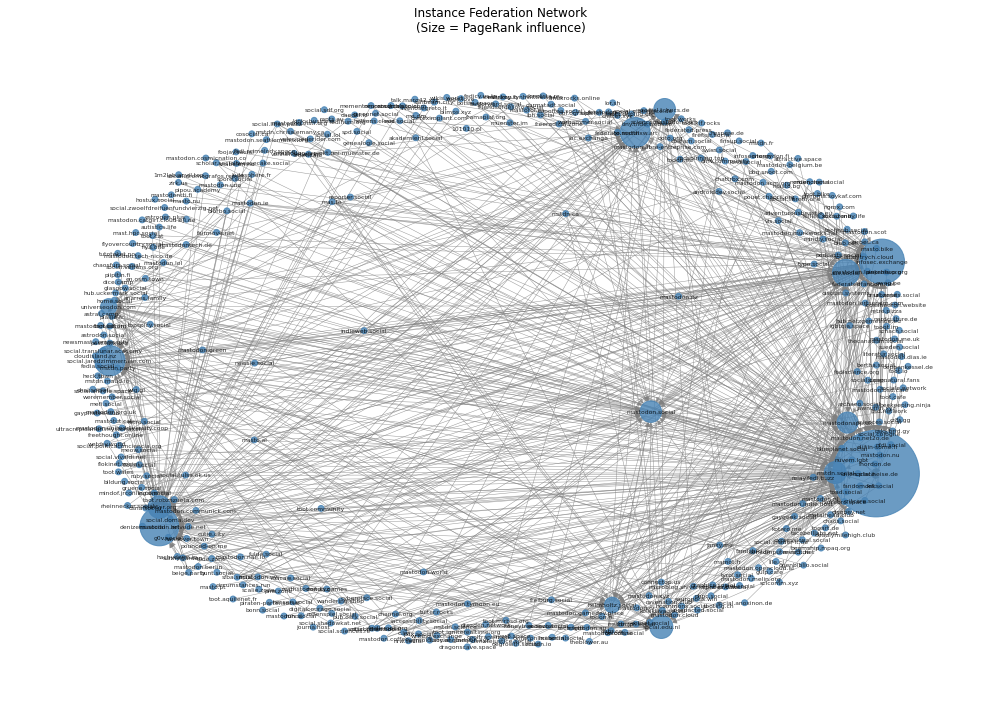

 Network analysis complete. Saved:
  users_with_centrality.csv
  snapshot_network_stats.csv
  instance_centrality.csv
  network_user.png
  network_instances.png


In [7]:
# --------------User network visualisation -----------------------#
# We will be using Gephy software to generate a graph for this visualisation
# Adding all computed attributes to graph nodes before exporting graphml file for use in Gephy
for node in G_full.nodes():
    uid = node
    user_row = df_users_clean[df_users_clean["user_id"].astype(str) == uid]
    if len(user_row) > 0:
        G_full.nodes[node]["pagerank"]    = float(pagerank.get(uid, 0))
        G_full.nodes[node]["betweenness"] = float(betweenness.get(uid, 0))
        G_full.nodes[node]["in_degree"]   = float(in_degree.get(uid, 0))
        G_full.nodes[node]["community"]   = int(partition.get(uid, -1))
        G_full.nodes[node]["is_migrant"]  = bool(user_row.iloc[0]["is_migrant"])
        G_full.nodes[node]["instance"]    = str(user_row.iloc[0]["instance"])

# Export both networks
nx.write_graphml(G_full, "mastodon_data_network/network_users.graphml")
nx.write_graphml(G_inst, "mastodon_data_network/network_instances.graphml")

# ------------------Instance network visualisation --------------------------#
plt.figure(figsize=(14, 10))
node_sizes_inst = [inst_pr.get(n, 0.001) * 30000 for n in G_inst.nodes()]
nx.draw_networkx(G_inst, nx.spring_layout(G_inst, seed=42, k=2),
                 node_color="steelblue",
                 node_size=node_sizes_inst,
                 edge_color="grey", arrows=True,
                 with_labels=True, font_size=6,
                 alpha=0.8, width=0.5)
plt.title("Instance Federation Network\n(Size = PageRank influence)")
plt.axis("off")
plt.tight_layout()
plt.savefig("mastodon_data_network/network_instances.png", dpi=150)
plt.show()

# -------------------------Save outputs------------------------------#
import os
os.makedirs("mastodon_data_network", exist_ok=True)

df_users_clean.to_csv("mastodon_data_network/users_with_centrality.csv", index=False)
df_snap_stats.to_csv("mastodon_data_network/snapshot_network_stats.csv",  index=False)
pd.DataFrame({
    "instance":    list(inst_pr.keys()),
    "pagerank":    list(inst_pr.values()),
    "betweenness": [inst_bt.get(i, 0) for i in inst_pr.keys()]
}).sort_values("pagerank", ascending=False).to_csv(
    "mastodon_data_network/instance_centrality.csv", index=False)

print(" Network analysis complete. Saved:")
print("  users_with_centrality.csv")
print("  snapshot_network_stats.csv")
print("  instance_centrality.csv")
print("  network_user.png")
print("  network_instances.png")